# Módulo 2: Estadística y Visualización de Datos
- **Sesión:** 02
- **Fecha:** 08/11/2025
- **Actualización:** 08/08/2026

## Objetivos de la sesión
1. Construir y manipular `Series` y `DataFrames` de pandas.
2. Leer archivos CSV y modificar registros con `.loc` y máscaras booleanas.
3. Calcular estadísticos descriptivos con numpy, scipy, statsmodels y pandas, entendiendo la diferencia entre varianza **poblacional** ($\sigma^2$, `ddof=0`) y **muestral** ($s^2$, `ddof=1`).
4. Calcular intervalos de confianza para la media.
5. Calcular e interpretar una matriz de correlación con matplotlib y seaborn.

> 📝 Los ejercicios están **propuestos** a lo largo del notebook. Las soluciones se encuentran en el notebook `semana_02_soluciones.ipynb`.

In [194]:
import pandas as pd
import numpy as np

print("pandas:", pd.__version__)
print("numpy:", np.__version__)

pandas: 2.2.3
numpy: 2.1.3


# Pandas

https://pandas.pydata.org/

**Pandas** es la librería estándar de Python para análisis de datos tabulares. Ofrece dos estructuras principales que veremos en orden: primero la **Series** (unidimensional) y luego el **DataFrame** (bidimensional), que se construye a partir de Series.

## 1. Series

### Teoría

Una **Series** es un arreglo **unidimensional etiquetado**: cada valor $x_i$ tiene asociada una etiqueta de índice $i$. Matemáticamente podemos verla como un vector columna acompañado de su índice:

$$
s \;=\;
\begin{array}{c|c}
\textbf{índice} & \textbf{valor} \\
\hline
i_0 & x_0 \\
i_1 & x_1 \\
\vdots & \vdots \\
i_{n-1} & x_{n-1}
\end{array}
\qquad\Longleftrightarrow\qquad
\vec{x} = \begin{pmatrix} x_0 \\ x_1 \\ \vdots \\ x_{n-1} \end{pmatrix}
$$

Características clave:
- Si no se especifica índice, pandas asigna $0, 1, 2, \dots, n-1$ automáticamente.
- El índice puede ser **personalizado** (fechas, nombres, códigos), lo que permite acceder por etiqueta y no solo por posición.
- Todos los valores comparten un **tipo de dato** (`dtype`).
- Las operaciones son **vectorizadas**: $s + 2$ suma 2 a *cada* elemento, sin bucles.

### Laboratorio: creación de Series

In [195]:
# Desde una lista
nro_list = [10, 20, 40, 60, 80]
serie_pd = pd.Series(nro_list)
print(serie_pd)

0    10
1    20
2    40
3    60
4    80
dtype: int64


In [196]:
# Desde un range (pares del 2 al 20)
serie_pares = pd.Series(range(2, 21, 2))
print(type(serie_pares))
serie_pares

<class 'pandas.core.series.Series'>


0     2
1     4
2     6
3     8
4    10
5    12
6    14
7    16
8    18
9    20
dtype: int64

In [197]:
# Desde un ndarray de numpy
nro_np = np.array([10, 20, 40, 60, 80])
serie_np = pd.Series(nro_np)
print(serie_np)

0    10
1    20
2    40
3    60
4    80
dtype: int64


In [198]:
# Desde np.arange (pares del 2 al 100)
serie_pares_np = pd.Series(np.arange(2, 101, 2))
serie_pares_np.head(10)

0     2
1     4
2     6
3     8
4    10
5    12
6    14
7    16
8    18
9    20
dtype: int64

In [199]:
# Con índice personalizado: acceso por etiqueta
notas = pd.Series([15, 18, 12, 19], index=["Ana", "Juan", "Maria", "Luis"])
print(notas)
print()
print("Nota de Juan:", notas["Juan"])

Ana      15
Juan     18
Maria    12
Luis     19
dtype: int64

Nota de Juan: 18


In [200]:
# Operaciones vectorizadas y filtrado con máscara booleana
print("Notas + 1 punto:")
print(notas + 1)


Notas + 1 punto:
Ana      16
Juan     19
Maria    13
Luis     20
dtype: int64


In [201]:
print("Aprobados (nota >= 14):")
print(notas[notas >= 14])

Aprobados (nota >= 14):
Ana     15
Juan    18
Luis    19
dtype: int64


### 📝 Ejercicio 1 — Creación de Series

Cree una serie de pandas **de dos maneras diferentes** a partir de la lista $[1, 3, 5, \dots, 33]$.
Además, cree una serie de pandas de dos maneras diferentes a partir del ndarray $[4, 8, 12, \dots, 44]$.

In [202]:
# Escriba su solución aquí
import pandas as pd

s = pd.Series(range(1,35,2))
print(s)

s = pd.Series(np.arange(1,35,2))
print(s)



0      1
1      3
2      5
3      7
4      9
5     11
6     13
7     15
8     17
9     19
10    21
11    23
12    25
13    27
14    29
15    31
16    33
dtype: int64
0      1
1      3
2      5
3      7
4      9
5     11
6     13
7     15
8     17
9     19
10    21
11    23
12    25
13    27
14    29
15    31
16    33
dtype: int64


In [203]:
lista2 = list(range(4,48,4))
data2 = np.array(lista2)

serie_lista_2 = pd.Series(data2)
print(serie_lista_2)

0      4
1      8
2     12
3     16
4     20
5     24
6     28
7     32
8     36
9     40
10    44
dtype: int64


### 📝 Ejercicio 2 — Series con índice personalizado

Cree una serie con las temperaturas máximas de una semana en Lima:
`[19, 21, 24, 26, 23, 20, 18]`, usando como índice los días `["Lun", "Mar", "Mie", "Jue", "Vie", "Sab", "Dom"]`.

1. Muestre la temperatura del día `Jue`.
2. Filtre los días con temperatura mayor a $22\,°C$.
3. Calcule la temperatura media de la semana.

In [204]:
# Escriba su solución aquí


## 2. DataFrames

### Teoría

Un **DataFrame** es una tabla bidimensional con filas y columnas etiquetadas. Podemos verlo como una matriz $X$ de $n$ filas (registros) y $m$ columnas (variables), donde **cada columna es una Series**:

$$
X \;=\;
\begin{array}{c|ccc}
 & \text{col}_1 & \cdots & \text{col}_m \\
\hline
\text{fila}_1 & x_{11} & \cdots & x_{1m} \\
\text{fila}_2 & x_{21} & \cdots & x_{2m} \\
\vdots & \vdots & \ddots & \vdots \\
\text{fila}_n & x_{n1} & \cdots & x_{nm}
\end{array}
\qquad X \in \mathbb{R}^{\,n \times m}
$$

Características clave:
- Cada columna tiene su propio `dtype` (una puede ser texto y otra numérica).
- El acceso recomendado es `df.loc[fila, columna]` (por etiqueta) o `df.iloc[i, j]` (por posición).
- Es la estructura equivalente a una hoja de cálculo o a una tabla de base de datos.

### Laboratorio: de diccionarios a DataFrames

Partimos de un diccionario de diccionarios, donde cada clave es el ID de un docente.

In [205]:
listado_docentes = {
    "0001": {"nombres": "Ana Maria",   "apellidos": "Lopez Garcia",      "edad": 34},
    "0002": {"nombres": "Juan Carlos", "apellidos": "Perez Soto",        "edad": 45},
    "0003": {"nombres": "Maria Elena", "apellidos": "Rodriguez Mendoza", "edad": 28},
}

print(listado_docentes["0002"])
print(listado_docentes["0002"]["nombres"])

{'nombres': 'Juan Carlos', 'apellidos': 'Perez Soto', 'edad': 45}
Juan Carlos


Si pasamos el diccionario directamente a `pd.DataFrame`, cada docente queda como **columna**:

In [206]:
df_columnas = pd.DataFrame(listado_docentes)
df_columnas

,0001,0002,0003
nombres,Ana Maria,Juan Carlos,Maria Elena
apellidos,Lopez Garcia,Perez Soto,Rodriguez Mendoza
edad,34,45,28


Esa orientación funciona, pero lo habitual en análisis de datos es que **cada fila sea un registro** (formato *tidy*), igual que en un CSV. Para eso usamos `orient="index"`:

In [207]:
df = pd.DataFrame.from_dict(listado_docentes, orient="index")
df

,nombres,apellidos,edad
0001,Ana Maria,Lopez Garcia,34
0002,Juan Carlos,Perez Soto,45
0003,Maria Elena,Rodriguez Mendoza,28


### Selección de datos

La forma recomendada de acceder a filas y columnas es `.loc[fila, columna]`:

In [208]:
# Fila completa del docente 0002
df.loc["0002"]

nombres      Juan Carlos
apellidos     Perez Soto
edad                  45
Name: 0002, dtype: object

In [209]:
# Un valor puntual: nombres del docente 0002
df.loc["0002", "nombres"]

'Juan Carlos'

In [210]:
df.head()

,nombres,apellidos,edad
0001,Ana Maria,Lopez Garcia,34
0002,Juan Carlos,Perez Soto,45
0003,Maria Elena,Rodriguez Mendoza,28


### Agregar registros

Con la orientación por filas, agregar un docente es agregar una **fila** con `.loc`:

In [211]:
# Duplicamos el registro 0001 como nuevo registro 0004
df.loc["0004"] = df.loc["0001"]
df

,nombres,apellidos,edad
0001,Ana Maria,Lopez Garcia,34
0002,Juan Carlos,Perez Soto,45
0003,Maria Elena,Rodriguez Mendoza,28
0004,Ana Maria,Lopez Garcia,34


### 📝 Ejercicio 3 — Acceso y filas en DataFrames

Sobre el DataFrame `df` de docentes:

1. Mostrar la edad del registro con ID = `0002`.
2. Agregar un registro al DataFrame duplicando el registro con ID = `0003` (asignarle el ID `0005`).

In [212]:
# Escriba su solución aquí

edad_0002 = df.loc["0002", "edad"]

print(f"Edad del docente con ID 0002: {edad_0002}")

print(50*"-")

df.loc["0005"] = df.loc["0003"]

df

Edad del docente con ID 0002: 45
--------------------------------------------------


,nombres,apellidos,edad
0001,Ana Maria,Lopez Garcia,34
0002,Juan Carlos,Perez Soto,45
0003,Maria Elena,Rodriguez Mendoza,28
0004,Ana Maria,Lopez Garcia,34
0005,Maria Elena,Rodriguez Mendoza,28


### Crear una columna derivada de otras columnas

In [213]:
df["nombre_completo"] = df["nombres"] + " " + df["apellidos"]
df

,nombres,apellidos,edad,nombre_completo
0001,Ana Maria,Lopez Garcia,34,Ana Maria Lopez Garcia
0002,Juan Carlos,Perez Soto,45,Juan Carlos Perez Soto
0003,Maria Elena,Rodriguez Mendoza,28,Maria Elena Rodriguez Mendoza
0004,Ana Maria,Lopez Garcia,34,Ana Maria Lopez Garcia
0005,Maria Elena,Rodriguez Mendoza,28,Maria Elena Rodriguez Mendoza


In [214]:
# ver columnas
df.columns

exist = "apellidos" in df.columns

print(f"Existe la columna 'apellidos'?: {exist}")

Existe la columna 'apellidos'?: True


In [215]:
# Insertar una columna en una posición específica (menos habitual).
# Nota: insert falla si la columna ya existe, por eso verificamos primero
# para que la celda pueda re-ejecutarse sin error.
if "anio_nacimiento" not in df.columns:
    df.insert(1, "anio_nacimiento", 2026 - df["edad"])
df

,nombres,anio_nacimiento,apellidos,edad,nombre_completo
0001,Ana Maria,1992,Lopez Garcia,34,Ana Maria Lopez Garcia
0002,Juan Carlos,1981,Perez Soto,45,Juan Carlos Perez Soto
0003,Maria Elena,1998,Rodriguez Mendoza,28,Maria Elena Rodriguez Mendoza
0004,Ana Maria,1992,Lopez Garcia,34,Ana Maria Lopez Garcia
0005,Maria Elena,1998,Rodriguez Mendoza,28,Maria Elena Rodriguez Mendoza


### Actualización de valores


In [216]:
df.loc["0001", "nombres"] = "Jaime"
df.head()

,nombres,anio_nacimiento,apellidos,edad,nombre_completo
0001,Jaime,1992,Lopez Garcia,34,Ana Maria Lopez Garcia
0002,Juan Carlos,1981,Perez Soto,45,Juan Carlos Perez Soto
0003,Maria Elena,1998,Rodriguez Mendoza,28,Maria Elena Rodriguez Mendoza
0004,Ana Maria,1992,Lopez Garcia,34,Ana Maria Lopez Garcia
0005,Maria Elena,1998,Rodriguez Mendoza,28,Maria Elena Rodriguez Mendoza


### 📝 Ejercicio 4 — Actualización de valores

Para el registro `0001` del DataFrame de docentes: cambiar la edad a `35` y el apellido a `"Rubio"`.

> Nota: la edad es numérica; asignar `"35"` (texto) convertiría la columna a tipo `object`. Mantengan los tipos consistentes.

In [ ]:
# Escriba su solución aquí
df.loc["0001", ["edad", "apellidos"]] = [35, "Rubio"]
df.head()

,nombres,anio_nacimiento,apellidos,edad,nombre_completo
0001,Jaime,1992,Rubio,35,Ana Maria Lopez Garcia
0002,Juan Carlos,1981,Perez Soto,45,Juan Carlos Perez Soto
0003,Maria Elena,1998,Rodriguez Mendoza,28,Maria Elena Rodriguez Mendoza
0004,Ana Maria,1992,Lopez Garcia,34,Ana Maria Lopez Garcia
0005,Maria Elena,1998,Rodriguez Mendoza,28,Maria Elena Rodriguez Mendoza


In [ ]:
df.loc["0001", "edad"] = 35
df.loc["0001", "apellidos"] = "Rubio"
df.head()

,nombres,anio_nacimiento,apellidos,edad,nombre_completo
0001,Jaime,1992,Rubio,35,Ana Maria Lopez Garcia
0002,Juan Carlos,1981,Perez Soto,45,Juan Carlos Perez Soto
0003,Maria Elena,1998,Rodriguez Mendoza,28,Maria Elena Rodriguez Mendoza
0004,Ana Maria,1992,Lopez Garcia,34,Ana Maria Lopez Garcia
0005,Maria Elena,1998,Rodriguez Mendoza,28,Maria Elena Rodriguez Mendoza


### 📝 Ejercicio 5 — Columnas derivadas y filtrado

Sobre el DataFrame de docentes:

1. Cree la columna `nombre_completo` uniendo `nombres` y `apellidos`.
2. Filtre los docentes con edad mayor a $30$ años.

In [ ]:
# Escriba su solución aquí
df["nombre_completo"] = df["nombres"] + " " + df["apellidos"]

df_mayores = df.loc[df["edad"] > 30]

df_mayores

,nombres,anio_nacimiento,apellidos,edad,nombre_completo
0001,Jaime,1992,Rubio,35,Jaime Rubio
0002,Juan Carlos,1981,Perez Soto,45,Juan Carlos Perez Soto
0004,Ana Maria,1992,Lopez Garcia,34,Ana Maria Lopez Garcia


### Lectura de archivos CSV

In [ ]:
df = pd.read_csv("dataset/panamericanos/medallero_Panamericanos_Santiago2023.csv")

# Me muestra las primeras 5 filas del DataFrame
df.head()

,Posicion,Pais,Oro,Plata,Bronce,Total,RankingTotal,Zona
0,1,Estados Unidos,124,75,87,286,1,America del Norte
1,2,Brasil,66,73,66,205,2,America del Sur
2,3,México,52,38,52,142,4,America del Norte
3,4,Canadá,46,55,63,164,3,America del Norte
4,5,Cuba,30,22,17,69,8,Caribe


In [226]:
# Buscar CUBA y cambiar las medallas de Plata a 21

df.loc[df["Pais"] == "Cuba", "Plata"] = 21

df.head()

,Posicion,Pais,Oro,Plata,Bronce,Total,RankingTotal,Zona
0,1,EEUU,124,75,87,286,1,America del Norte
1,2,Brasil,65,73,66,204,2,America del Sur
2,3,México,52,38,52,142,4,America del Norte
3,4,Canadá,46,55,63,164,3,America del Norte
4,5,Cuba,30,21,17,69,8,Caribe


In [229]:
# Ordenar dataFrame por la columna Total de forma descendente
df1 = df.sort_values(by="Total", ascending=False).head(3)

df1

,Posicion,Pais,Oro,Plata,Bronce,Total,RankingTotal,Zona
0,1,EEUU,124,75,87,286,1,America del Norte
1,2,Brasil,65,73,66,204,2,America del Sur
3,4,Canadá,46,55,63,164,3,America del Norte


### 📝 Ejercicio 6 — Modificación de un CSV

Con el medallero de los Panamericanos Santiago 2023:

1. Cambiar el nombre de país de `Estados Unidos` a `EEUU`.
2. Cambiar la cantidad de medallas de Oro de Brasil a `65` y actualizar el Total de medallas.

>  Use **máscaras booleanas**.

In [222]:
# Escriba su solución aquí
df.loc[0, "Pais"] = "EEUU"
df.head()
df.loc[1, "Oro"] = 65

# Recalculamos la columna Total
df["Total"] = df["Oro"] + df["Plata"] + df["Bronce"]

df.head()

,Posicion,Pais,Oro,Plata,Bronce,Total,RankingTotal,Zona
0,1,EEUU,124,75,87,286,1,America del Norte
1,2,Brasil,65,73,66,204,2,America del Sur
2,3,México,52,38,52,142,4,America del Norte
3,4,Canadá,46,55,63,164,3,America del Norte
4,5,Cuba,30,22,17,69,8,Caribe


In [223]:
df.loc[df["Pais"] == "Estados Unidos", "Pais"] = "EEUU"

df.loc[df["Pais"] == "Brasil", "Oro"] = 65

df.loc[df["Pais"] == "Brasil", "Total"] = (
    df.loc[df["Pais"] == "Brasil", "Oro"] +
    df.loc[df["Pais"] == "Brasil", "Plata"] +
    df.loc[df["Pais"] == "Brasil", "Bronce"]
)

df.head()

,Posicion,Pais,Oro,Plata,Bronce,Total,RankingTotal,Zona
0,1,EEUU,124,75,87,286,1,America del Norte
1,2,Brasil,65,73,66,204,2,America del Sur
2,3,México,52,38,52,142,4,America del Norte
3,4,Canadá,46,55,63,164,3,America del Norte
4,5,Cuba,30,22,17,69,8,Caribe


In [224]:
df.loc[0, "Pais"] = "EEUU"
df.loc[1, "Oro"] = 65

df["Total"] = df["Oro"] + df["Plata"] + df["Bronce"]

df.head()

,Posicion,Pais,Oro,Plata,Bronce,Total,RankingTotal,Zona
0,1,EEUU,124,75,87,286,1,America del Norte
1,2,Brasil,65,73,66,204,2,America del Sur
2,3,México,52,38,52,142,4,America del Norte
3,4,Canadá,46,55,63,164,3,America del Norte
4,5,Cuba,30,22,17,69,8,Caribe


### 📝 Ejercicio 7 — Ordenamiento y filtrado del medallero

Con el medallero original (vuelva a leer el CSV):

1. Muestre el **top 5** de países por Total de medallas usando `sort_values`.
2. Muestre los países que obtuvieron más de $20$ medallas de oro.

In [117]:
# Escriba su solución aquí


# Estadísticos descriptivos

La **estadística descriptiva** resume y describe las características principales de un conjunto de datos, sin sacar conclusiones más allá de la muestra observada. Los estadísticos se agrupan en dos familias:

## 1. Medidas de tendencia central
Indican alrededor de qué valor se concentran los datos.

- **Media aritmética** ($\bar{x}$): suma de todos los valores dividida entre la cantidad de observaciones. Es sensible a valores extremos (*outliers*).

$$\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i$$

- **Mediana** ($\tilde{x}$): valor que ocupa la posición central cuando los datos están ordenados. Divide al conjunto en dos mitades y es **robusta** frente a outliers.

$$\tilde{x} = \begin{cases} x_{\left(\frac{n+1}{2}\right)} & \text{si } n \text{ es impar} \\[6pt] \dfrac{x_{\left(\frac{n}{2}\right)} + x_{\left(\frac{n}{2}+1\right)}}{2} & \text{si } n \text{ es par} \end{cases}$$

- **Moda**: valor que aparece con mayor frecuencia. Puede no existir (todos los valores distintos) o haber más de una (distribución multimodal). Es la única medida de tendencia central aplicable a datos categóricos.

## 2. Medidas de dispersión
Indican qué tan alejados están los datos respecto al centro.

- **Rango**: $R = x_{max} - x_{min}$
- **Varianza**: promedio de las desviaciones al cuadrado respecto a la media. Se expresa en unidades al cuadrado.

$$\text{Poblacional:}\quad \sigma^2 = \frac{1}{N}\sum_{i=1}^{N}(x_i - \mu)^2 \qquad\qquad \text{Muestral:}\quad s^2 = \frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2$$

> **¿Por qué $n-1$ en la muestral?** Cuando estimamos la varianza de una población a partir de una muestra, usamos $\bar{x}$ en lugar de la media real $\mu$. Esto hace que las desviaciones queden sistemáticamente subestimadas; dividir entre $n-1$ (corrección de Bessel) compensa ese sesgo. El parámetro `ddof` (*delta degrees of freedom*) de las librerías controla precisamente esto: `ddof=0` → poblacional, `ddof=1` → muestral.

- **Desviación estándar**: raíz cuadrada de la varianza. Tiene la ventaja de estar en las **mismas unidades** que los datos originales.

$$\sigma = \sqrt{\sigma^2} \qquad\qquad s = \sqrt{s^2}$$

- **Percentiles y cuartiles**: el percentil $p$ es el valor por debajo del cual queda el $p\%$ de los datos. Los cuartiles son los percentiles 25 ($Q_1$), 50 ($Q_2$ = mediana) y 75 ($Q_3$).
- **Rango intercuartílico**: $IQR = Q_3 - Q_1$. Mide la dispersión del 50% central de los datos y es robusto frente a outliers.

---

Trabajaremos con un mismo arreglo de ejemplo para comparar cuatro librerías (statsmodels, scipy, numpy y pandas). Incluimos valores **repetidos** para que la moda tenga sentido.

In [118]:
a_matrix = np.array([0, 1, 2, 3, 4, 5, 5, 6, 7, 8, 9, 10, 11, 12, 13, 5])
a_matrix

array([ 0,  1,  2,  3,  4,  5,  5,  6,  7,  8,  9, 10, 11, 12, 13,  5])

## Con statsmodels

**statsmodels** es una librería orientada a modelos estadísticos formales (regresiones, pruebas de hipótesis, series de tiempo). Su clase `DescrStatsW` calcula estadísticos descriptivos y admite datos ponderados.

- https://www.statsmodels.org/stable/index.html

In [119]:
import statsmodels.api as sm

desc = sm.stats.DescrStatsW(a_matrix)

print("Media:", desc.mean)
print("Desviación estándar:", desc.std)
print("Varianza:", desc.var)
print("Cuartiles:")
print(desc.quantile([0.25, 0.5, 0.75]))

Media: 6.3125
Desviación estándar: 3.803267509655349
Varianza: 14.46484375
Cuartiles:
p
0.25    3
0.50    5
0.75    9
dtype: int64


## Con scipy

**SciPy** es la librería de computación científica de Python; su módulo `scipy.stats` incluye distribuciones de probabilidad, pruebas estadísticas y estadísticos descriptivos. Las funciones con prefijo `t` (`tmin`, `tmean`, `tvar`...) son versiones *trimmed* que permiten opcionalmente excluir valores fuera de un rango.

- https://scipy.org/

In [120]:
import scipy.stats as stats

print("Mínimo:", stats.tmin(a_matrix))
print("Máximo:", stats.tmax(a_matrix))
print("Media:", stats.tmean(a_matrix))
print("Varianza:", stats.tvar(a_matrix))          # ojo: scipy usa ddof=1 (muestral) por defecto
print("Desviación estándar:", stats.tstd(a_matrix))
print("Percentil 25:", stats.scoreatpercentile(a_matrix, 25))
print("Percentil 50:", stats.scoreatpercentile(a_matrix, 50))
print("Percentil 75:", stats.scoreatpercentile(a_matrix, 75))
print("Rango intercuartílico:", stats.iqr(a_matrix))
print("Moda:", stats.mode(a_matrix).mode, "- frecuencia:", stats.mode(a_matrix).count)

Mínimo: 0
Máximo: 13
Media: 6.3125
Varianza: 15.429166666666667
Desviación estándar: 3.927997793617846
Percentil 25: 3.75
Percentil 50: 5.5
Percentil 75: 9.25
Rango intercuartílico: 5.5
Moda: 5 - frecuencia: 3


## Con métodos del ndarray (numpy)

In [121]:
print("Suma:", a_matrix.sum())
print("Media:", a_matrix.mean())
print("Mínimo:", a_matrix.min())
print("Máximo:", a_matrix.max())
print("Varianza:", a_matrix.var())                # numpy usa ddof=0 (poblacional) por defecto
print("Desviación estándar:", a_matrix.std())

Suma: 101
Media: 6.3125
Mínimo: 0
Máximo: 13
Varianza: 14.46484375
Desviación estándar: 3.803267509655349


### Estadísticos por eje (matrices 2D)

Para una matriz $X \in \mathbb{R}^{n \times m}$, `axis=0` calcula el estadístico por **columnas** y `axis=1` por **filas**.

In [122]:
m = np.arange(0, 16).reshape(4, 4)
m

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15]])

In [123]:
AXIS = 1  # 0: por columnas, 1: por filas
print(m)
print("Suma:", m.sum(axis=AXIS))
print("Media:", m.mean(axis=AXIS))
print("Mínimo:", m.min(axis=AXIS))
print("Máximo:", m.max(axis=AXIS))
print("Varianza:", m.var(axis=AXIS))
print("Desviación estándar:", m.std(axis=AXIS))

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]]
Suma: [ 6 22 38 54]
Media: [ 1.5  5.5  9.5 13.5]
Mínimo: [ 0  4  8 12]
Máximo: [ 3  7 11 15]
Varianza: [1.25 1.25 1.25 1.25]
Desviación estándar: [1.11803399 1.11803399 1.11803399 1.11803399]


## Con funciones de numpy

In [124]:
print("Suma:", np.sum(a_matrix))
print("Mínimo:", np.min(a_matrix))
print("Máximo:", np.max(a_matrix))
print("Media:", np.mean(a_matrix))
print("Mediana:", np.median(a_matrix))
print("Varianza:", np.var(a_matrix))
print("Desviación estándar:", np.std(a_matrix))
print("Percentil 25:", np.percentile(a_matrix, 25))
print("Percentil 50:", np.percentile(a_matrix, 50))
print("Percentil 75:", np.percentile(a_matrix, 75))

Suma: 101
Mínimo: 0
Máximo: 13
Media: 6.3125
Mediana: 5.5
Varianza: 14.46484375
Desviación estándar: 3.803267509655349
Percentil 25: 3.75
Percentil 50: 5.5
Percentil 75: 9.25


In [125]:
# Por eje: axis=0 columnas, axis=1 filas
print("Suma:", np.sum(m, axis=0))
print("Media:", np.mean(m, axis=0))
print("Mediana:", np.median(m, axis=0))
print("Varianza:", np.var(m, axis=0))
print("Desviación estándar:", np.std(m, axis=0))
print("Percentil 50:", np.percentile(m, 50, axis=0))

Suma: [24 28 32 36]
Media: [6. 7. 8. 9.]
Mediana: [6. 7. 8. 9.]
Varianza: [20. 20. 20. 20.]
Desviación estándar: [4.47213595 4.47213595 4.47213595 4.47213595]
Percentil 50: [6. 7. 8. 9.]


## Con pandas

⚠️ **Diferencia clave entre librerías:**

| Librería | Por defecto | Fórmula |
|---|---|---|
| numpy | `ddof=0` → **poblacional** | $\sigma^2 = \frac{1}{N}\sum(x_i - \mu)^2$ |
| pandas | `ddof=1` → **muestral** | $s^2 = \frac{1}{n-1}\sum(x_i - \bar{x})^2$ |
| scipy | `ddof=1` → **muestral** | $s^2 = \frac{1}{n-1}\sum(x_i - \bar{x})^2$ |

Por eso los resultados pueden diferir entre librerías si no se especifica `ddof`.

In [126]:
ds = pd.Series(a_matrix)

print("Mínimo:", ds.min())
print("Máximo:", ds.max())
print("Media:", ds.mean())
print("Mediana:", ds.median())
print("Moda:", ds.mode()[0])
print("Percentil 25:", ds.quantile(0.25))
print("Percentil 50:", ds.quantile(0.50))
print("Percentil 75:", ds.quantile(0.75))
print()
print("Varianza por defecto (muestral, ddof=1) =", ds.var())
print("Varianza poblacional (ddof=0)          =", ds.var(ddof=0))
print("Desv. estándar por defecto (ddof=1)    =", ds.std())
print("Desv. estándar poblacional (ddof=0)    =", ds.std(ddof=0))

Mínimo: 0
Máximo: 13
Media: 6.3125
Mediana: 5.5
Moda: 5
Percentil 25: 3.75
Percentil 50: 5.5
Percentil 75: 9.25

Varianza por defecto (muestral, ddof=1) = 15.429166666666667
Varianza poblacional (ddof=0)          = 14.46484375
Desv. estándar por defecto (ddof=1)    = 3.927997793617846
Desv. estándar poblacional (ddof=0)    = 3.803267509655349


### 📝 Ejercicio 8 — Funciones de varianza

Cree una función para calcular la **varianza poblacional**

$$\sigma^2 = \frac{1}{N}\sum_{i=1}^{N}(x_i - \mu)^2$$

y otra para la **varianza muestral**

$$s^2 = \frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2$$

que admitan como argumento un ndarray. Aplíquelas al conjunto de edades $22, 18, 35, 23, 41, 28, 45$ y compare los resultados con los métodos de numpy.

In [127]:
# Escriba su solución aquí


### 📝 Ejercicio 9 — Estadísticos del medallero

Leer la información de los Panamericanos de Santiago 2023 y calcular la **media**, **mediana** y **desviación estándar** de la medalla de Oro.

In [128]:
# Escriba su solución aquí


# Cargar CSV y asignar nombres a columnas

Dataset: https://archive.ics.uci.edu/dataset/53/iris

In [129]:
titles = ["sepal_length", "sepal_width", "petal_length", "petal_width", "class"]

data = pd.read_csv("dataset/iris.csv", names=titles)
data.head()

,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [130]:
# Buen hábito: inspeccionar tamaño y tipos al cargar cualquier dataset
print("Registros:", len(data))
data.info()

Registros: 150
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   class         150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [131]:
# Media de la columna "sepal_length"
media = data["sepal_length"].mean()
print(f"{media:.2f} cm")

5.84 cm


## Intervalo de confianza para la media

### Teoría

Un estadístico calculado sobre una muestra (como $\bar{x}$) es una **estimación puntual**: un único número que difícilmente coincide exactamente con el parámetro poblacional ($\mu$). Un **intervalo de confianza (IC)** complementa esa estimación con un rango de valores plausibles:

$$IC = \bar{x} \pm z_{\alpha/2} \cdot \underbrace{\frac{s}{\sqrt{n}}}_{\text{error estándar}}$$

donde $\frac{s}{\sqrt{n}}$ es el **error estándar de la media** (`st.sem` en scipy) y $z_{\alpha/2}$ es el valor crítico de la distribución ($z_{0.025} \approx 1.96$ para el $95\%$ con la normal).

**Interpretación correcta:** un IC al 95% significa que, si repitiéramos el muestreo muchas veces y construyéramos un intervalo cada vez, aproximadamente el 95% de esos intervalos contendría la verdadera media poblacional. *No* significa que hay 95% de probabilidad de que $\mu$ esté en este intervalo particular.

**¿Normal o t de Student?**
- Con muestras **grandes** (regla práctica: $n > 30$), el Teorema Central del Límite justifica usar la distribución **normal**.
- La forma **general** (válida también para muestras pequeñas, cuando $\sigma$ es desconocida) usa la distribución **t de Student** con $n-1$ grados de libertad. Con $n$ grande, ambas dan resultados casi idénticos.

### Laboratorio

Como $n = 150 > 30$, podemos usar la normal; mostramos también la versión con t para comparar.

In [132]:
import scipy.stats as st

n = len(data["sepal_length"])
media = data["sepal_length"].mean()
error_estandar = st.sem(data["sepal_length"])

# Con distribución normal (n > 30)
ic_norm = st.norm.interval(confidence=0.95, loc=media, scale=error_estandar)

# Forma general con t de Student (df = n - 1)
ic_t = st.t.interval(confidence=0.95, df=n - 1, loc=media, scale=error_estandar)

print(f"Media de la longitud del sépalo: {media:.2f} cm")
print(f"IC 95% (normal): ({ic_norm[0]:.4f}, {ic_norm[1]:.4f})")
print(f"IC 95% (t)     : ({ic_t[0]:.4f}, {ic_t[1]:.4f})")

Media de la longitud del sépalo: 5.84 cm
IC 95% (normal): (5.7108, 5.9758)
IC 95% (t)     : (5.7097, 5.9769)


### 📝 Ejercicio 10 — Estadísticos del ancho de pétalos

Calcular: mínimo, máximo, media, mediana, moda, varianza poblacional ($\sigma^2$), varianza muestral ($s^2$), desviación estándar poblacional ($\sigma$) y desviación estándar muestral ($s$) para el **ancho de los pétalos** del dataset iris.

In [133]:
# Escriba su solución aquí


### 📝 Ejercicio 11 — Intervalo de confianza al 99%

Calcular el intervalo de confianza al $99\%$ del ancho de los pétalos de la muestra de iris:

$$IC = \bar{x} \pm z_{\alpha/2} \cdot \frac{s}{\sqrt{n}}$$

In [134]:
# Escriba su solución aquí


### 📝 Ejercicio 12 — Detección de outliers con la regla del IQR

Un criterio habitual para detectar valores atípicos (*outliers*) es la **regla del rango intercuartílico**: un valor es atípico si está fuera del intervalo

$$[\,Q_1 - 1.5 \cdot IQR,\;\; Q_3 + 1.5 \cdot IQR\,] \qquad \text{donde } IQR = Q_3 - Q_1$$

Aplique esta regla a la columna `sepal_width` del dataset iris: calcule $Q_1$, $Q_3$, el $IQR$, los límites, y muestre cuántos y cuáles valores son atípicos.

In [135]:
# Escriba su solución aquí


## Correlación

### Teoría

La **correlación** mide la fuerza y dirección de la relación **lineal** entre dos variables numéricas. El coeficiente más usado es el de **Pearson**:

$$r = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2}\;\sqrt{\sum_{i=1}^{n}(y_i - \bar{y})^2}} = \frac{\text{cov}(x, y)}{s_x \, s_y}$$

El valor de $r$ siempre está entre $-1$ y $1$:

| Valor de $r$ | Interpretación |
|---|---|
| $r = 1$ | Correlación positiva perfecta |
| $0.7 \leq r < 1$ | Correlación positiva fuerte |
| $0.3 \leq r < 0.7$ | Correlación positiva moderada |
| $r \approx 0$ | Sin relación lineal |
| $-0.7 < r \leq -0.3$ | Correlación negativa moderada |
| $-1 < r \leq -0.7$ | Correlación negativa fuerte |
| $r = -1$ | Correlación negativa perfecta |

**Precauciones importantes:**
- **Correlación no implica causalidad**: que dos variables se muevan juntas no significa que una cause a la otra (puede haber una tercera variable, o coincidencia).
- Pearson solo detecta relaciones **lineales**: dos variables pueden tener una relación fuerte pero no lineal (por ejemplo, en forma de U) y dar $r \approx 0$.
- Solo aplica a variables **numéricas**; las categóricas requieren otros métodos.


<img src="imagenes/tipos-correlacion.png" width="500">

### Laboratorio

In [136]:
# Estadísticos descriptivos con pandas
data.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


No se puede calcular la correlación sobre columnas categóricas, por lo que seleccionamos solo las columnas numéricas. Una forma robusta es `select_dtypes`, que no requiere conocer el nombre de la columna categórica:

In [137]:
data_num = data.select_dtypes(include="number")
# Equivalente: data.drop(columns=["class"])

corr_matrix = data_num.corr()
corr_matrix

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.109369,0.871754,0.817954
sepal_width,-0.109369,1.000000,-0.420516,-0.356544
petal_length,0.871754,-0.420516,1.000000,0.962757
petal_width,0.817954,-0.356544,0.962757,1.000000


### Matriz de correlaciones con matplotlib

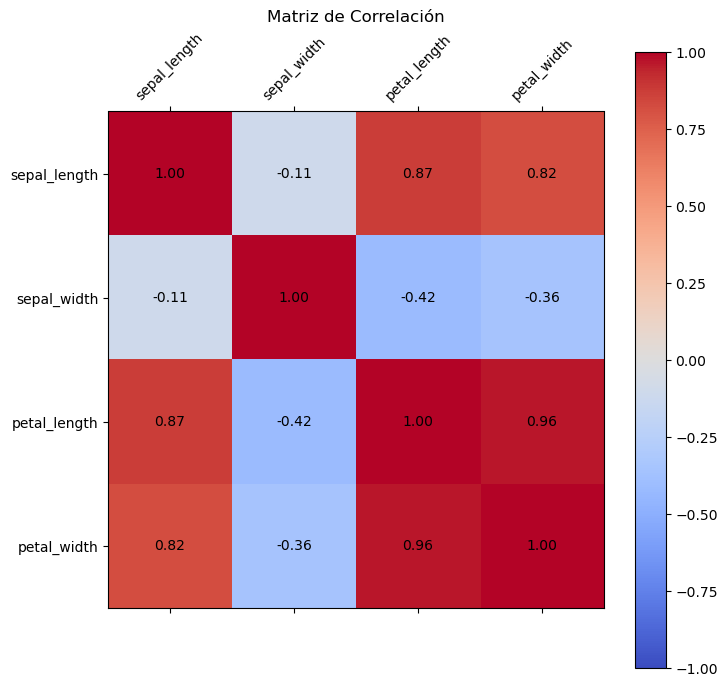

In [138]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))
cax = ax.matshow(corr_matrix, vmin=-1, vmax=1, cmap="coolwarm")
fig.colorbar(cax)

ticks = np.arange(len(data_num.columns))
ax.set_xticks(ticks, labels=data_num.columns, rotation=45)
ax.set_yticks(ticks, labels=data_num.columns)

# Anotar los valores en cada celda
valores = corr_matrix.to_numpy()
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        ax.text(j, i, f"{valores[i, j]:.2f}", ha="center", va="center", color="black")

plt.title("Matriz de Correlación")
plt.show()

### Mapa de calor con seaborn (forma más directa)

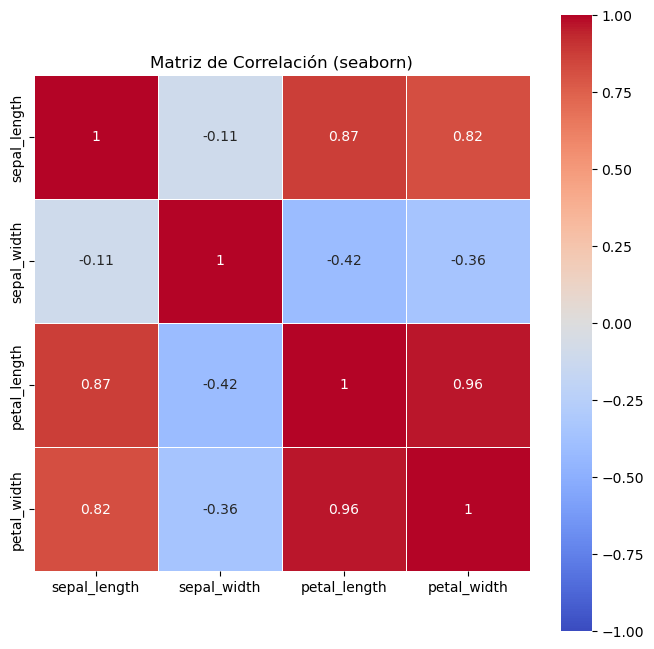

In [139]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1,
            linewidths=0.5, square=True)
plt.title("Matriz de Correlación (seaborn)")
plt.show()

### Interpretación
- `petal_length` y `petal_width` tienen correlación positiva muy fuerte ($r \approx 0.96$): pétalos más largos tienden a ser más anchos.
- `sepal_width` correlaciona negativamente con las medidas del pétalo.
- La diagonal siempre vale $1$ (correlación de una variable consigo misma).

### 📝 Ejercicio 13 — Interpretación de la correlación

A partir de la matriz de correlación del dataset iris:

1. Identifique el **par de variables distintas** con mayor correlación (en valor absoluto).
2. Grafique un diagrama de dispersión (*scatter plot*) de ese par de variables con `plt.scatter`.
3. Interprete: ¿la relación observada en el gráfico es coherente con el valor de $r$?

In [140]:
# Escriba su solución aquí
